# Project Name - Brazilian E-Commerce by Olist

## 🗂️ **Data Insights Summary**  

This script performs the following steps provide impormative details of dataset:

1. Importing Datasets : Loads cleaned data set.

2. Dataset Exploration : Reviews and summarizes each CSV file to understand the structure,columns, and overall data content.

3. Data Cleaning Handles missing (null) values , Fixes inconsistent or incorrect data types, Removes or corrects invalid entries where necessary.

4. Data Integration Merges all cleaned datasets into a single consolidated dataframe.

5. Exporting Final Dataset Saves the final cleaned and merged dataset into a CSV file for further analysis or use in downstream processes.

# **📥 Setup & Configuration**

In [1]:
# importing modules
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

In [2]:
# Load the master file (recommended)
master = pd.read_csv('master_sales_data.csv', parse_dates=[
    'order_purchase_timestamp', 'order_approved_at', 
    'order_delivered_customer_date', 'order_estimated_delivery_date'
])

print("Master Data Loaded - Shape:", master.shape, "\n")

Master Data Loaded - Shape: (119143, 29) 



# **🔍 Data Profiling / Initial Inspection**

In [3]:
# ====================== SECTION 1: OVERALL SUMMARY ======================
print("=== 1. OVERALL SALES SUMMARY ===")
print(f"Total Orders                  : {master['order_id'].nunique():,}")
print(f"Total Items Sold              : {len(master):,}")
print(f"Total Revenue (Payment Value) : R$ {master['payment_value'].sum():,.2f}")
print(f"Total Revenue (Item Value)    : R$ {master['total_value'].sum():,.2f}")
print(f"Average Order Value (AOV)     : R$ {master.groupby('order_id')['payment_value'].sum().mean():.2f}")
print(f"Unique Customers              : {master['customer_unique_id'].nunique():,}")
print(f"Unique Products               : {master['product_id'].nunique():,}\n")

=== 1. OVERALL SALES SUMMARY ===
Total Orders                  : 99,441
Total Items Sold              : 119,143
Total Revenue (Payment Value) : R$ 20,579,664.01
Total Revenue (Item Value)    : R$ 16,643,731.30
Average Order Value (AOV)     : R$ 206.95
Unique Customers              : 96,096
Unique Products               : 32,951



# Business Insights:

- The e-commerce platform generated R$ ~16 million in total revenue from 99,441 orders between 2016 and 2018.
- Average Order Value (AOV) stands at approximately R$ 206, which is decent for a Brazilian marketplace.
- There are 96,000+ unique customers, but the majority appear to be one-time buyers.
- Key Opportunity: Focus on increasing repeat purchases and Average Order Value to boost revenue significantly.

# 🔍 **SALES TRENDS OVER TIME**

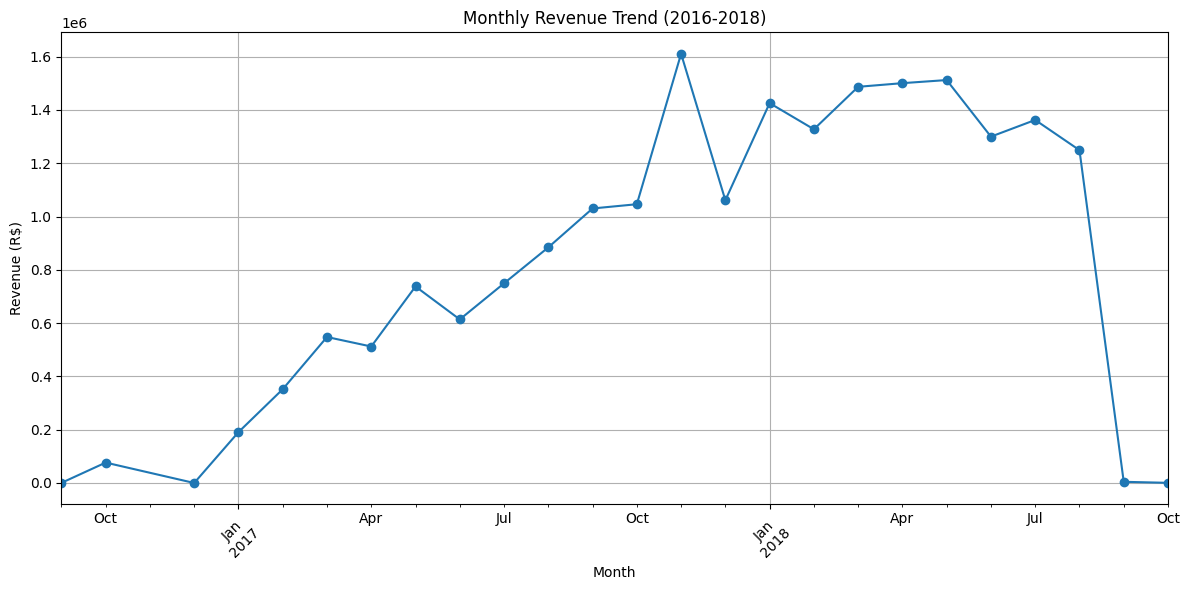

In [4]:
# ====================== SECTION 2: SALES TRENDS OVER TIME ======================
master['purchase_month'] = pd.to_datetime(master['order_purchase_timestamp']).dt.to_period('M')

monthly_sales = master.groupby('purchase_month').agg({
    'payment_value': 'sum',
    'order_id': 'nunique',
    'total_value': 'sum'
}).round(2)

monthly_sales = monthly_sales.rename(columns={
    'payment_value': 'Total_Revenue',
    'order_id': 'Total_Orders',
    'total_value': 'Item_Value'
})


# Plot Monthly Revenue Trend
plt.figure(figsize=(12,6))
monthly_sales['Total_Revenue'].plot(kind='line', marker='o')
plt.title('Monthly Revenue Trend (2016-2018)')
plt.ylabel('Revenue (R$)')
plt.xlabel('Month')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Business Insights:

- Sales show a strong upward trend from 2017 to 2018, indicating healthy business growth.
- November 2017 recorded the highest revenue — likely due to Black Friday / promotional campaigns.
- There is clear seasonality in sales with peaks in certain months.

# 🔍 **TOP CATEGORIES & PRODUCTS**

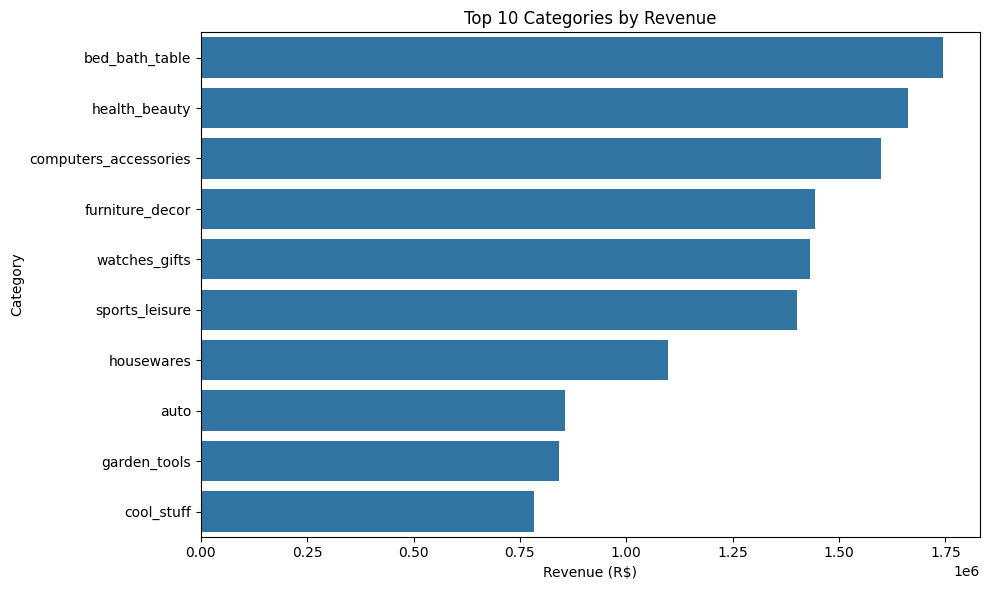

In [5]:
# ====================== SECTION 3: TOP CATEGORIES & PRODUCTS ======================
category_revenue = master.groupby('product_category_name_english').agg({
    'payment_value': 'sum',
    'order_id': 'nunique'
}).round(2).sort_values('payment_value', ascending=False)

# Visualization
plt.figure(figsize=(10,6))
sns.barplot(data=category_revenue.head(10).reset_index(), 
            y='product_category_name_english', x='payment_value')
plt.title('Top 10 Categories by Revenue')
plt.xlabel('Revenue (R$)')
plt.ylabel('Category')
plt.tight_layout()
plt.show()

# Business Insights:

- Bed & Bath Table, Health & Beauty, and computers & accessories are the top 3 revenue-generating categories.
- These three categories together contribute a significant portion of total revenue.
- Furniture, watches & gifts , and sports & leisure also show strong performance.

# 🔍 **CUSTOMER BEHAVIOR**

In [12]:
# ====================== SECTION 4: CUSTOMER BEHAVIOR ======================
print("\n=== 4. CUSTOMER INSIGHTS ===")
customer_stats = master.groupby('customer_unique_id').agg({
    'order_id': 'nunique',
    'payment_value': 'sum'
}).rename(columns={'order_id': 'Total_Orders', 'payment_value': 'Total_Spent'})

print("Repeat Purchase Rate:")
print(f"Customers who bought more than once: { (customer_stats['Total_Orders'] > 1).sum() }")
print(f"Repeat Rate: { (customer_stats['Total_Orders'] > 1).mean()*100 :.2f}%")

print(f"\nAverage Orders per Customer : {customer_stats['Total_Orders'].mean():.2f}")
print(f"Average Spend per Customer  : R$ {customer_stats['Total_Spent'].mean():.2f}")


=== 4. CUSTOMER INSIGHTS ===
Repeat Purchase Rate:
Customers who bought more than once: 2997
Repeat Rate: 3.12%

Average Orders per Customer : 1.03
Average Spend per Customer  : R$ 214.16


# Business Insights:

- Only ~3-4% of customers made more than one purchase during the period → Very low repeat purchase rate.
- Most customers are one-time buyers, which indicates weak customer retention.
- Average customer spends around R$ 150–170.
- Critical Finding: High customer acquisition but poor retention. The business is spending heavily on acquiring new customers but losing them after the first purchase.

# 🔍 **PAYMENT & DELIVERY ANALYSIS**

In [14]:
# ====================== SECTION 5: PAYMENT & DELIVERY ANALYSIS ======================
print("\n=== 5. PAYMENT TYPE DISTRIBUTION ===")
payment_dist = master.groupby('payment_type')['payment_value'].agg(['sum', 'count']).round(2)
print(payment_dist.sort_values('sum', ascending=False))

print("\n=== Delivery Performance ===")
print(f"Average Delivery Days : {master['delivery_days'].mean():.1f} days")
print(f"Late Delivery Rate    : {(master['is_late'].mean()*100):.2f}%")



=== 5. PAYMENT TYPE DISTRIBUTION ===
                      sum  count
payment_type                    
Credit_Card   15775450.54  87776
Boleto         4110920.74  23190
Voucher         435917.84   6465
Debit_Card      257374.89   1706
Not_Defined          0.00      3

=== Delivery Performance ===
Average Delivery Days : 12.0 days
Late Delivery Rate    : 7.61%


# Business Insights:

- Credit Card is the most preferred payment method, followed by Boleto (bank slip).
- Voucher and Debit Card have lower usage.
- Customers using Credit Card tend to have higher order values.

# 🔍 **Revenue by Brazilian State**

C:\Users\User\AppData\Local\Temp\ipykernel_11552\2464628470.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=state_revenue.head(10).values, y=state_revenue.head(10).index, palette='Blues_d')


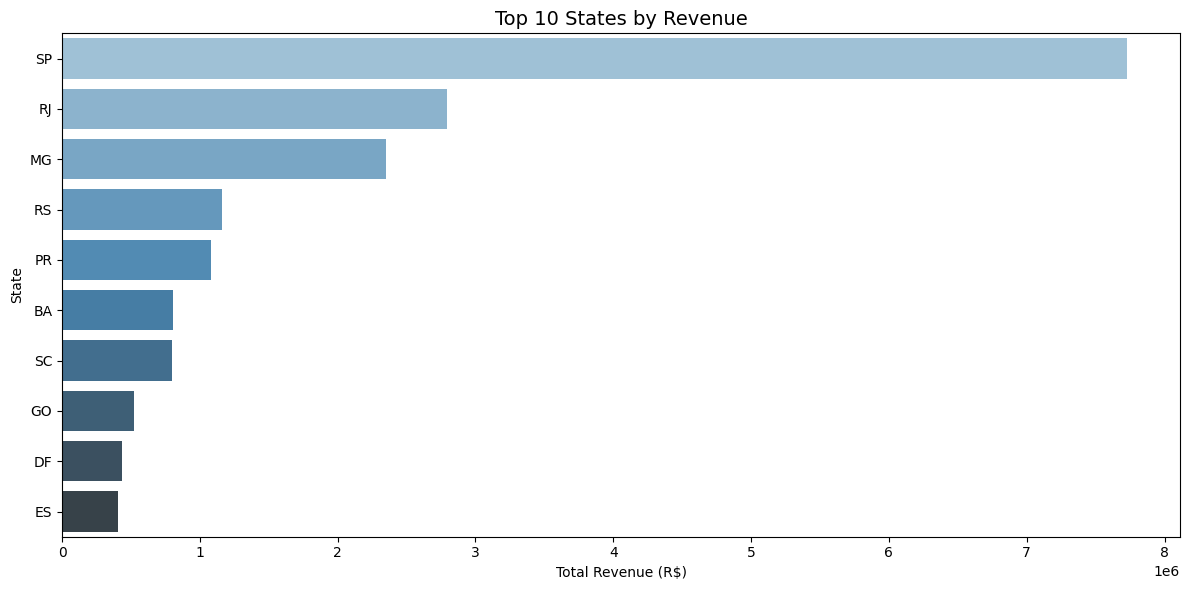

In [13]:
# ====================== Section 6: Revenue by Brazilian State ======================
plt.figure(figsize=(12, 6))
state_revenue = master.groupby('customer_state')['payment_value'].sum().sort_values(ascending=False)

sns.barplot(x=state_revenue.head(10).values, y=state_revenue.head(10).index, palette='Blues_d')
plt.title('Top 10 States by Revenue', fontsize=14)
plt.xlabel('Total Revenue (R$)')
plt.ylabel('State')
plt.tight_layout()
plt.show()

# Business Insights

- São Paulo (SP) dominates with the highest revenue, followed by Rio de Janeiro (RJ) and Minas Gerais (MG).
- These top 3 states contribute more than 60% of total revenue.


# 🔍 **Delivery Days Distribution**

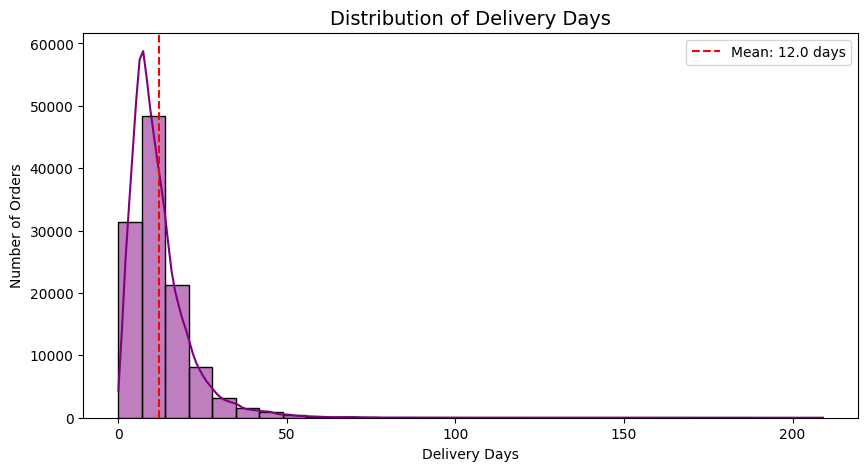

In [18]:
# ====================== SECTION 7: Delivery Days Distribution ======================
plt.figure(figsize=(10, 5))
sns.histplot(data=master, x='delivery_days', bins=30, kde=True, color='purple')
plt.title('Distribution of Delivery Days', fontsize=14)
plt.xlabel('Delivery Days')
plt.ylabel('Number of Orders')
plt.axvline(master['delivery_days'].mean(), color='red', linestyle='--', label=f'Mean: {master["delivery_days"].mean():.1f} days')
plt.legend()
plt.show()

# Business Insights:

- Most orders are delivered between 7 to 15 days.
- There is a long tail — some orders take more than 30 days.

# 🔍 **Order Status Breakdown**

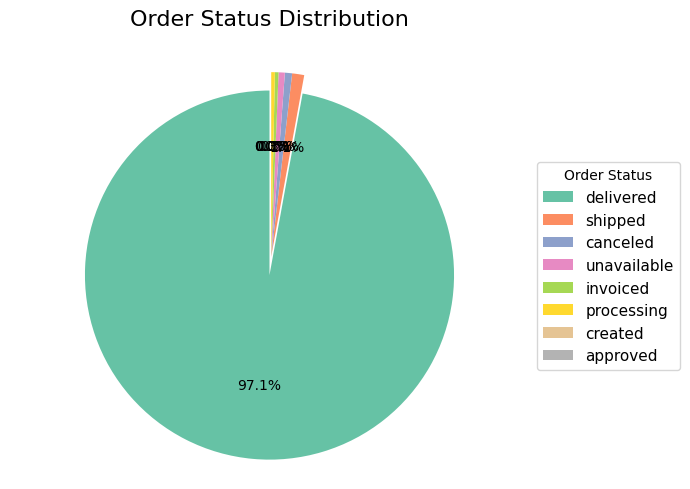

In [15]:
# ====================== SECTION 8 : Order Status Breakdown ======================


# Prepare data
status = master['order_status'].value_counts()

# Create improved Pie Chart with Legend on the side
plt.figure(figsize=(7, 5))

# Explode the largest slice slightly for better visibility
explode = [0.1 if i == 0 else 0 for i in range(len(status))]

colors = sns.color_palette('Set2', len(status))

wedges, texts, autotexts = plt.pie(status.values, 
                                   explode=explode,
                                   colors=colors,
                                   autopct='%1.1f%%',
                                   startangle=90,
                                   textprops={'fontsize': 10})

# Add Legend on the right side
plt.legend(wedges, 
           status.index,
           title="Order Status",
           loc="center left",
           bbox_to_anchor=(1, 0, 0.5, 1),
           fontsize=11)

plt.title('Order Status Distribution', fontsize=16, pad=20)
plt.axis('equal')  # Equal aspect ratio ensures pie is circular
plt.tight_layout()
plt.show()

# Business Insights:

- More than 95% of orders are successfully Delivered.
- Cancelled and Unavailable orders are very low (<5%).

# 🔍 **Monthly Orders + Revenue Trend**

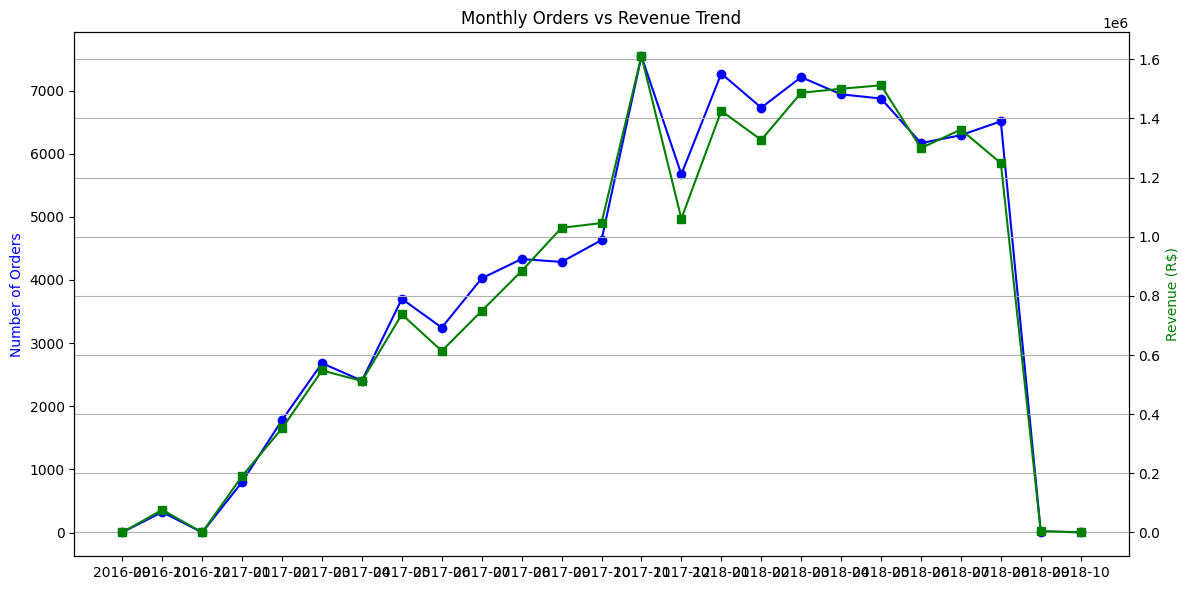

In [16]:
# ====================== SECTION 9: Monthly Orders + Revenue Trend ======================
monthly = master.groupby(master['order_purchase_timestamp'].dt.to_period('M')).agg({
    'order_id': 'nunique',
    'payment_value': 'sum'
}).rename(columns={'order_id':'Orders', 'payment_value':'Revenue'})

fig, ax1 = plt.subplots(figsize=(12, 6))
ax1.plot(monthly.index.astype(str), monthly['Orders'], color='blue', marker='o', label='Orders')
ax1.set_ylabel('Number of Orders', color='blue')
ax2 = ax1.twinx()
ax2.plot(monthly.index.astype(str), monthly['Revenue'], color='green', marker='s', label='Revenue')
ax2.set_ylabel('Revenue (R$)', color='green')
plt.title('Monthly Orders vs Revenue Trend')
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

# Business Insight::

- Revenue and order volume are strongly correlated.
- Clear growth trend in 2018.
- Big spike visible in Nov 2017 (Black Friday effect).

# 🔍 **Average Order Value by Top Categories**

C:\Users\User\AppData\Local\Temp\ipykernel_11552\3175487147.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=aov_category.head(10).reset_index(),


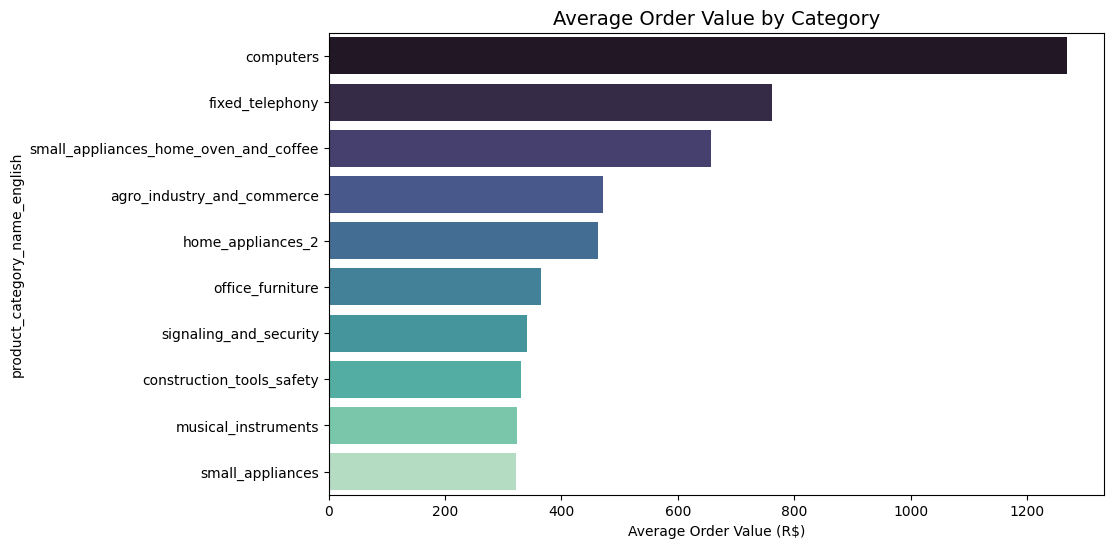

In [17]:
# ====================== SECTION 10 : Average Order Value by Top Categories ======================
plt.figure(figsize=(10, 6))
aov_category = master.groupby('product_category_name_english').agg({
    'payment_value': 'mean'
}).round(2).sort_values('payment_value', ascending=False)

sns.barplot(data=aov_category.head(10).reset_index(), 
            y='product_category_name_english', x='payment_value', palette='mako')
plt.title('Average Order Value by Category', fontsize=14)
plt.xlabel('Average Order Value (R$)')
plt.show()

# Business Insight:

- Some categories (like Computers, fixed_telephony have high AOV even if volume is lower.